# Toy Gaussian Field: LS / ELS / bbELS Entropy vs Noise

This notebook builds a toy **translationally invariant Gaussian field** dataset with Fourier-space covariance

\[
\mathbb{E}\,|\hat{x}(k)|^2 = A\,|k|^{-\alpha}
\]

and estimates finite-sample posterior entropy at different noise levels for:

- `LS`: posterior over finite clean samples
- `ELS`: posterior over finite clean samples plus **circular translations**
- `bbELS`: posterior over finite clean samples plus **zero-padded translations** (boundary-broken)


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

os.chdir("../")
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import math
from dataclasses import dataclass

from torch.utils.data import TensorDataset

from src.utils.data import get_dataset
from src.utils.idealscore import LocalEquivBordersScoreModule, LocalEquivScoreModule, LocalScoreModule
from src.utils.noise_schedules import cosine_noise_schedule

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [6]:
def default_amplitude_from_measure(image_size, alpha, device="cpu"):
    """Choose A so that integral dmu(k) * A * k^{-alpha} = 1 with dmu normalized to 1."""
    ky = torch.fft.fftfreq(image_size, d=1.0, device=device)[:, None]
    kx = torch.fft.rfftfreq(image_size, d=1.0, device=device)[None, :]
    k = torch.sqrt(kx**2 + ky**2)
    k_nonzero = k[k > 0]

    lambda_ir = torch.min(k_nonzero)
    lambda_uv = torch.max(k_nonzero)
    norm = 0.5 * (lambda_uv**2 - lambda_ir**2)

    # Integral approximation over [lambda_ir, lambda_uv] for k^{-alpha} under dmu=k dk / norm.
    k_grid = torch.linspace(lambda_ir, lambda_uv, 4096, device=device)
    integrand = (k_grid / norm) * torch.pow(k_grid, -alpha)
    ik = torch.trapezoid(integrand, k_grid)
    return float((1.0 / ik).item())


def sample_powerlaw_gaussian_field(
    n_samples,
    image_size,
    alpha=3.0,
    amplitude=None,
    seed=0,
    device="cpu",
    return_amplitude=False,
):
    """Sample real 2D Gaussian fields with spectrum A|k|^{-alpha}."""
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)

    if amplitude is None:
        amplitude = default_amplitude_from_measure(image_size=image_size, alpha=alpha, device=device)

    ky = torch.fft.fftfreq(image_size, d=1.0, device=device)[:, None]
    kx = torch.fft.rfftfreq(image_size, d=1.0, device=device)[None, :]
    k = torch.sqrt(kx**2 + ky**2)

    power = amplitude * torch.where(k > 0, k.pow(-alpha), torch.zeros_like(k))
    # Interior: scale = sqrt(power/2). Only x-edges (kx=0, kx=N/2) need double variance; y-edges do not (rfft stores all ky but only kx>=0).
    scale = torch.sqrt(torch.clamp(power, min=0.0) / 2.0)
    ix = torch.arange(image_size // 2 + 1, device=device)
    col_edge = (ix == 0) | (ix == image_size // 2)
    scale = torch.where(col_edge[None, :], torch.sqrt(torch.clamp(power, min=0.0)), scale)
    iy = torch.arange(image_size, device=device)
    row_edge = (iy == 0) | (iy == image_size // 2)
    corner_mode = row_edge[:, None] & col_edge[None, :]

    coeff_real = torch.randn((n_samples, image_size, image_size // 2 + 1), generator=gen, device=device)
    coeff_imag = torch.randn((n_samples, image_size, image_size // 2 + 1), generator=gen, device=device)
    coeff_imag = torch.where(corner_mode[None, :, :], torch.zeros_like(coeff_imag), coeff_imag)
    coeff = (coeff_real + 1j * coeff_imag) * scale[None, :, :]
    coeff[:, 0, 0] = 0.0  # remove mean mode

    x = torch.fft.irfft2(coeff, s=(image_size, image_size), norm="ortho")
    x = x - x.mean(dim=(1, 2), keepdim=True)
    x = x[:, None, :, :]

#     print(x)
    
    if return_amplitude:
        return x, float(amplitude)
    return x


In [7]:
@dataclass
class ToyConfig:
    dataset_name: str = "Toy Gaussian Field"
    image_size: int = 32
    n_train: int = 200000
    n_eval: int = 4
    alpha: float = 1.7
    amplitude: float | None = None
    score_batch_size: int = 8
    posterior_max_samples: int = 2000
    empty_cache_each_call: bool = True
    t_values: tuple = tuple(np.linspace(0.05, 0.95, 36).tolist())  # more points so slopes visible where I < ln|D|


cfg = ToyConfig()

effective_amplitude = cfg.amplitude
train_dataset = None

# Prefer disk-backed dataset (same loading path as CelebA) when available.
try:
    train_dataset, metadata = get_dataset("toy_gaussian_field", root="./data", train=True)
    valid_dataset, _ = get_dataset("toy_gaussian_field", root="./data", train=False)

    cfg.image_size = int(metadata["image_size"])
    cfg.alpha = float(metadata.get("alpha", cfg.alpha))
    effective_amplitude = float(metadata.get("amplitude", cfg.amplitude if cfg.amplitude is not None else 1.0))

    # Small evaluation tensor only.
    eval_n = min(cfg.n_eval, len(valid_dataset))
    eval_x0 = torch.stack([valid_dataset[i][0] for i in range(eval_n)], dim=0).to(device)  # test set for entropy evaluation
    print("Loaded disk-backed toy dataset from ./data/toy_gaussian_field")
except Exception:
    # Fallback: in-memory toy sample generation for quick experimentation.
    train_x0, effective_amplitude = sample_powerlaw_gaussian_field(
        cfg.n_train,
        cfg.image_size,
        alpha=cfg.alpha,
        amplitude=cfg.amplitude,
        seed=1,
        device=device,
        return_amplitude=True,
    )
    train_labels = torch.zeros(train_x0.shape[0], dtype=torch.long)
    train_dataset = TensorDataset(train_x0.detach().cpu(), train_labels)

    eval_x0 = sample_powerlaw_gaussian_field(  # test set for entropy evaluation
        cfg.n_eval,
        cfg.image_size,
        alpha=cfg.alpha,
        amplitude=effective_amplitude,
        seed=2,
        device=device,
    )

print("eval_x0:", tuple(eval_x0.shape))
print("train_dataset size:", len(train_dataset))
print("effective_amplitude:", effective_amplitude)


Loaded disk-backed toy dataset from ./data/toy_gaussian_field
eval_x0: (4, 3, 32, 32)
train_dataset size: 200000
effective_amplitude: 0.07999312256760648


In [10]:
def build_candidate_bank(score_machine_name, dataset, image_size, channels=3, score_batch_size=64, max_samples=5000):
    """Build score machine modules (LS/ELS/bbELS) using forward_with_posterior_stats where available."""
    common_kwargs = dict(
        kernel_size=3,
        batch_size=score_batch_size,
        image_size=image_size,
        channels=channels,
        schedule=cosine_noise_schedule,
        max_samples=max_samples,
        shuffle=False,
    )

    score_machine_name = score_machine_name.lower()
    if score_machine_name == "ls":
        mod = LocalScoreModule(
            dataset,
            kernel_size=3,
            image_size=image_size,
            batch_size=score_batch_size,
            schedule=cosine_noise_schedule,
            max_samples=max_samples,
        )
    elif score_machine_name == "els":
        mod = LocalEquivScoreModule(dataset, **common_kwargs)
    elif score_machine_name == "bbels":
        mod = LocalEquivBordersScoreModule(dataset, **common_kwargs)
    else:
        raise ValueError(f"Unknown score machine: {score_machine_name}")

    mod.to(device).eval()
    return mod


def posterior_entropy_nats_from_score_machine(score_machine, t, xt):
    """Use forward_with_posterior_stats to estimate entropy in nats."""
    if hasattr(score_machine, "forward_with_posterior_stats"):
        out = score_machine.forward_with_posterior_stats(t, xt, device=device, k=3)
        entropy_nats = out[2].mean().item()
        return float(entropy_nats)

    # Fallback for bbELS: use local module posterior stats proxy.
    if hasattr(score_machine, "local_module") and hasattr(score_machine.local_module, "forward_with_posterior_stats"):
        out = score_machine.local_module.forward_with_posterior_stats(t, xt, device=device, k=3)
        entropy_nats = out[2].mean().item()
        return float(entropy_nats)

    return float("nan")


train_posterior_samples = min(cfg.posterior_max_samples, len(train_dataset))
ls_machine = build_candidate_bank(
    "ls",
    train_dataset,
    image_size=cfg.image_size,
    channels=eval_x0.shape[1],
    score_batch_size=cfg.score_batch_size,
    max_samples=train_posterior_samples,
)
els_machine = build_candidate_bank(
    "els",
    train_dataset,
    image_size=cfg.image_size,
    channels=eval_x0.shape[1],
    score_batch_size=cfg.score_batch_size,
    max_samples=train_posterior_samples,
)
bbels_machine = build_candidate_bank(
    "bbels",
    train_dataset,
    image_size=cfg.image_size,
    channels=eval_x0.shape[1],
    score_batch_size=cfg.score_batch_size,
    max_samples=train_posterior_samples,
)

print("score machines ready (k=3).")
print("train_posterior_samples:", train_posterior_samples)
print("score_batch_size:", cfg.score_batch_size)

score machines ready (k=3).
train_posterior_samples: 2000
score_batch_size: 8


In [11]:
def square_radial_density(R, s):
    """Square radial density: 2*pi*R for R < s, 4*(arcsin(s/R) - arccos(s/R)) for s < R < sqrt(2)*s, 0 for R > sqrt(2)*s."""
    R = np.asarray(R, dtype=np.float64)
    out = np.zeros_like(R)
    sqrt2_s = np.sqrt(2.0) * s
    mask_small = (R > 0) & (R < s)
    mask_mid = (R >= s) & (R < sqrt2_s)
    out[mask_small] = 2.0 * np.pi * R[mask_small]
    # arcsin(s/R) - arccos(s/R) = 2*arcsin(s/R) - pi/2 for s/R in (0, 1]
    out[mask_mid] = 4.0 * R[mask_mid] * (np.arcsin(np.clip(s / R[mask_mid], 1e-12, 1.0)) - np.arccos(np.clip(s / R[mask_mid], 1e-12, 1.0)))
    return out


def square_continuum_mutual_information(snr_value, amplitude, alpha, s, patch_pixels, num_k=4096):
    """Continuum MI in nats using square radial density: (1/2) int dmu(R) log(1 + SNR*A*R^{-alpha}).
    dmu(R) = (density(R) / norm) dR with int dmu = patch_pixels."""
    sqrt2_s = np.sqrt(2.0) * s
    R_min = s * 1e-6  # avoid R=0
    R_grid = np.linspace(R_min, sqrt2_s, num_k, dtype=np.float64)
    rho = square_radial_density(R_grid, s)
    norm = np.trapz(rho, R_grid)
    if norm <= 0:
        return 0.0
    # dmu = (rho / norm) * patch_pixels so that int dmu = patch_pixels
    integrand = (rho / norm) * patch_pixels * 0.5 * np.log(1.0 + snr_value * amplitude * np.power(R_grid, -alpha))
    return float(np.trapz(integrand, R_grid))

## Analytic Entropy Prediction vs LS and ELS

**Continuum mutual information** (in nats):
$$
I_{\mathrm{cont}}(\mathrm{SNR}) = \frac{1}{2}\int_{\Lambda_{IR}}^{\Lambda_{UV}} d\mu(k)\,\log\left(1+\mathrm{SNR}\cdot A\,|k|^{-\alpha}\right).
$$

**Discrete mutual information** (in nats):
$$
I_{\mathrm{disc}}(\mathrm{SNR}) = \frac{1}{2}\sum_{\mathbf{k}} \log\left(1+\mathrm{SNR}\cdot A\,|\mathbf{k}|^{-\alpha}\right).
$$

Entropy is then $S = \max\{0, \log|D| - I\}$ (nats), with $I$ either $I_{\mathrm{cont}}$ or $I_{\mathrm{disc}}$. The code below defines `continuum_mutual_information`, `discrete_mutual_information`, and entropy functions that use them.

Spectral measure normalization:
$$
d\mu(k)=\frac{k\,dk}{N}, \qquad \int_{\Lambda_{IR}}^{\Lambda_{UV}}\frac{k}{N}\,dk = P,
$$
where $P$ is the number of pixels in the patch. In this notebook we use full-image patches, so $P=H\times W = L^2$. 

Also, $\Lambda_{IR}=\frac{1}{L}$ where L in the image side length and $\Lambda_{UV} = \frac{1}{\sqrt{2}}$

In [25]:
def continuum_mutual_information(snr_value, amplitude, alpha, lambda_ir, lambda_uv, patch_pixels, num_k=4096):
    """Continuum MI in nats: (1/2) int dmu(k) log(1 + SNR*A*|k|^{-alpha}), dmu(k) = (k/N) dk, int dmu = patch_pixels."""
    k = np.linspace(lambda_ir, lambda_uv, num_k, dtype=np.float64)
    integral_k = 0.5 * (lambda_uv**2 - lambda_ir**2)
    N = 2*integral_k / patch_pixels
    integrand = 0.5 * np.log(1.0 + snr_value/4 * amplitude * np.power(k, -alpha))
    return float(np.trapz((k / N) * integrand, k)/2.0)


def discrete_mutual_information(snr_value, amplitude, alpha, image_size, include_zero_mode=False):
    """Discrete MI in nats: (1/2) sum_k log(1 + SNR*A*|k|^{-alpha})."""
    ky = torch.fft.fftfreq(image_size, d=1.0, device=device)[:, None]
    kx = torch.fft.rfftfreq(image_size, d=1.0, device=device)[None, :]
    k = torch.sqrt(kx**2 + ky**2)

    power = amplitude * torch.where(k > 0, k.pow(-alpha), torch.zeros_like(k))
    # Interior: scale = sqrt(power/2). Only x-edges (kx=0, kx=N/2) need double variance; y-edges do not (rfft stores all ky but only kx>=0).
    scale = torch.sqrt(torch.clamp(power, min=0.0) / 2.0)
    ix = torch.arange(image_size // 2 + 1, device=device)
    col_edge = (ix == 0) | (ix == image_size // 2)
    scale = torch.where(col_edge[None, :], torch.sqrt(torch.clamp(power, min=0.0)), scale)
    iy = torch.arange(image_size, device=device)
    row_edge = (iy == 0) | (iy == image_size // 2)
    corner_mode = row_edge[:, None] & col_edge[None, :]

    real_scale = scale
    imag_scale = torch.where(corner_mode, torch.zeros_like(scale), scale)

    terms = 0.5 * torch.log(1.0 + snr_value * torch.square(real_scale)) + 0.5 * torch.log(1.0 + snr_value * torch.square(imag_scale))
    return float(torch.sum(terms))


def continuum_approximation_entropy_nats(snr_value, D_size, amplitude, alpha, lambda_ir, lambda_uv, patch_pixels, num_k=4096):
    """Entropy in nats: S = max(0, log|D| - I_cont) with I_cont = continuum_mutual_information(...)."""
    I_cont = continuum_mutual_information(snr_value, amplitude, alpha, lambda_ir, lambda_uv, patch_pixels, num_k)
    return max(0.0, np.log(D_size) - I_cont)


def discrete_entropy_nats(snr_value, D_size, amplitude, alpha, k_mag_grid, include_zero_mode=False):
    """Entropy in nats: S = max(0, log|D| - I_disc) with I_disc = discrete_mutual_information(...)."""
    I_disc = discrete_mutual_information(snr_value, amplitude, alpha, k_mag_grid, include_zero_mode)
    return max(0.0, np.log(D_size) - I_disc)


# Frequency cutoffs from the same discrete image grid
freq = np.fft.fftfreq(cfg.image_size, d=1.0)
ky, kx = np.meshgrid(freq, freq, indexing="ij")
k_mag = np.sqrt(kx**2 + ky**2)
k_nonzero = k_mag[k_mag > 0]
lambda_ir = float(np.min(k_nonzero))
lambda_uv = float(np.max(k_nonzero))

beta_values = np.array(results["snr"], dtype=np.float64)  # beta = SNR
patch_pixels = int(cfg.image_size * cfg.image_size)

D_ls = int(train_posterior_samples)
D_els = int(train_posterior_samples * cfg.image_size * cfg.image_size)

continuum_approximation_ls = [
    continuum_approximation_entropy_nats(b, D_ls, effective_amplitude, cfg.alpha, lambda_ir, lambda_uv, patch_pixels)
    for b in beta_values
]
continuum_approximation_els = [
    continuum_approximation_entropy_nats(b, D_els, effective_amplitude, cfg.alpha, lambda_ir, lambda_uv, patch_pixels)
    for b in beta_values
]

# Discrete MI (same I_disc for both LS and ELS); entropy S = max(0, ln|D| - I_disc)
discrete_mi = [
    discrete_mutual_information(s, effective_amplitude, cfg.alpha, cfg.image_size, include_zero_mode=False)
    for s in beta_values
]
analytic_ls_discrete = [max(0.0, np.log(D_ls) - mi) for mi in discrete_mi]
analytic_els_discrete = [max(0.0, np.log(D_els) - mi) for mi in discrete_mi]

print(f"lambda_ir={lambda_ir:.4f}, lambda_uv={lambda_uv:.4f}")
print("beta is set to SNR")
print(f"patch_pixels={patch_pixels}")
print(f"|D|_LS={D_ls}, |D|_ELS={D_els}")

lambda_ir=0.0312, lambda_uv=0.7071
beta is set to SNR
patch_pixels=1024
|D|_LS=2000, |D|_ELS=2048000


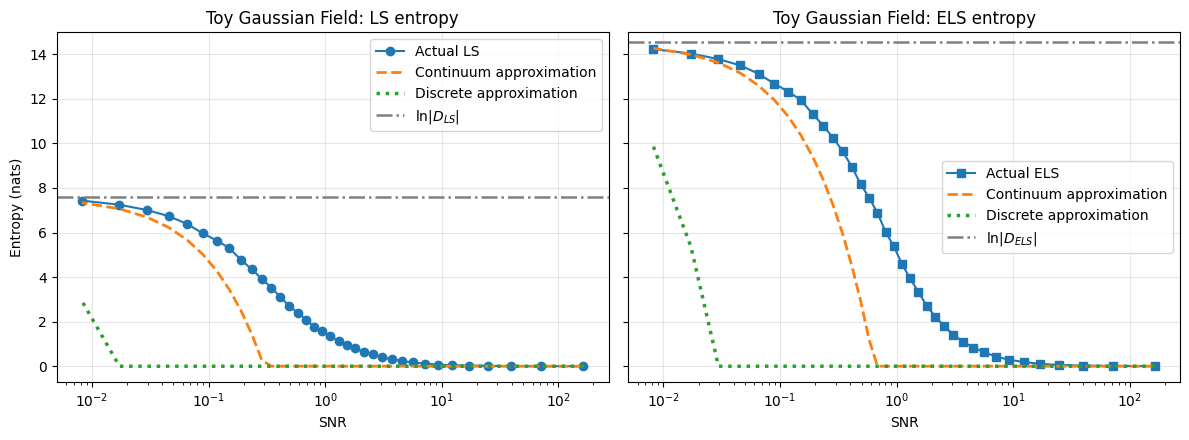

LS MAE (continuum_approximation) = 1.0787 nats | LS MAE (discrete) = 2.3840 nats
ELS MAE (continuum_approximation) = 2.0469 nats | ELS MAE (discrete) = 5.5299 nats


In [26]:
# Entropy S = max(0, ln|D| - I). The discrete MI I_disc is the same for LS and ELS; the curves
# differ because |D_LS| = train_posterior_samples and |D_ELS| = train_posterior_samples * H*W.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

logD_ls_nats = np.log(D_ls)
logD_els_nats = np.log(D_els)

# LS comparison
axes[0].plot(results["snr"], results["LS"], "o-", label="Actual LS")
axes[0].plot(results["snr"], continuum_approximation_ls, "--", linewidth=2.0, label="Continuum approximation")
axes[0].plot(results["snr"], analytic_ls_discrete, ":", linewidth=2.5, label="Discrete approximation")
axes[0].axhline(logD_ls_nats, color="gray", linestyle="-.", linewidth=1.8, label=r"$\ln|D_{LS}|$")
axes[0].set_xscale("log")
axes[0].set_xlabel("SNR")
axes[0].set_ylabel("Entropy (nats)")
axes[0].set_title(f"{cfg.dataset_name}: LS entropy")
axes[0].grid(alpha=0.3)
axes[0].legend()

# ELS comparison
axes[1].plot(results["snr"], results["ELS"], "s-", label="Actual ELS")
axes[1].plot(results["snr"], continuum_approximation_els, "--", linewidth=2.0, label="Continuum approximation")
axes[1].plot(results["snr"], analytic_els_discrete, ":", linewidth=2.5, label="Discrete approximation")
axes[1].axhline(logD_els_nats, color="gray", linestyle="-.", linewidth=1.8, label=r"$\ln|D_{ELS}|$")
axes[1].set_xscale("log")
axes[1].set_xlabel("SNR")
axes[1].set_title(f"{cfg.dataset_name}: ELS entropy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

ls_mae_cont = float(np.mean(np.abs(np.array(results["LS"]) - np.array(continuum_approximation_ls))))
ls_mae_disc = float(np.mean(np.abs(np.array(results["LS"]) - np.array(analytic_ls_discrete))))
els_mae_cont = float(np.mean(np.abs(np.array(results["ELS"]) - np.array(continuum_approximation_els))))
els_mae_disc = float(np.mean(np.abs(np.array(results["ELS"]) - np.array(analytic_els_discrete))))

print(f"LS MAE (continuum_approximation) = {ls_mae_cont:.4f} nats | LS MAE (discrete) = {ls_mae_disc:.4f} nats")
print(f"ELS MAE (continuum_approximation) = {els_mae_cont:.4f} nats | ELS MAE (discrete) = {els_mae_disc:.4f} nats")

In [12]:
# Test entropies: noisy observations xt are from eval_x0 (test/validation set), not training.
results = {"t": [], "snr": [], "LS": [], "ELS": [], "bbELS": []}

for t_val in cfg.t_values:
    t = torch.tensor([t_val], device=device, dtype=torch.float32)
    beta_t = cosine_noise_schedule(t)
    at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
    bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))

    with torch.no_grad():
        # Noisy test observation (eval_x0 = test set)
        eps = torch.randn_like(eval_x0, device=device)
        xt = at * eval_x0 + bt * eps

        h_ls = posterior_entropy_nats_from_score_machine(ls_machine, t, xt)
        if cfg.empty_cache_each_call and device.type == "cuda":
            torch.cuda.empty_cache()

        h_els = posterior_entropy_nats_from_score_machine(els_machine, t, xt)
        if cfg.empty_cache_each_call and device.type == "cuda":
            torch.cuda.empty_cache()

        h_bbels = posterior_entropy_nats_from_score_machine(bbels_machine, t, xt)
        if cfg.empty_cache_each_call and device.type == "cuda":
            torch.cuda.empty_cache()

    snr = ((1.0 - beta_t) / (beta_t + 1e-12)).item()
    results["t"].append(float(t_val))
    results["snr"].append(float(snr))
    results["LS"].append(h_ls)
    results["ELS"].append(h_els)
    results["bbELS"].append(h_bbels)

print("Finished. Example row:")
print({k: v[0] for k, v in results.items()})


Finished. Example row:
{'t': 0.05, 'snr': 164.05210876464844, 'LS': 0.00227374373935163, 'ELS': 0.0056501878425478935, 'bbELS': 0.0017679427983239293}


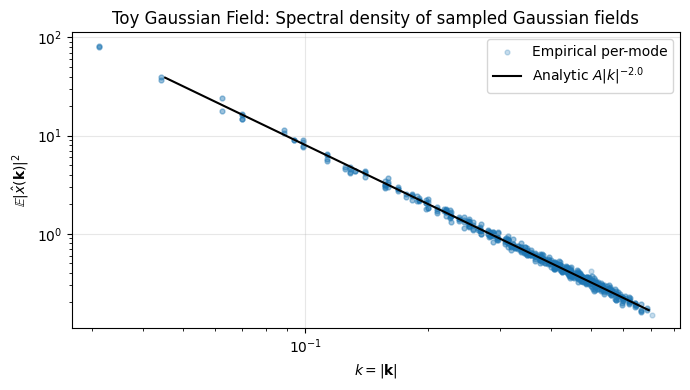

In [27]:
# Spectral density of sampled Gaussian fields
n_spectral = 256
samples_spectral = sample_powerlaw_gaussian_field(
    n_spectral,
    cfg.image_size,
    alpha=cfg.alpha,
    amplitude=effective_amplitude,
    seed=43,
    device=device,
)
x_np = samples_spectral[:, 0].cpu().numpy()  # [n, H, W]
fft_coeff = np.fft.fft2(x_np, axes=(-2, -1), norm="ortho")
emp_cov = np.mean(np.abs(fft_coeff) ** 2, axis=0)

freq = np.fft.fftfreq(cfg.image_size, d=1.0)
ky_full, kx_full = np.meshgrid(freq, freq, indexing="ij")
k_mag = np.sqrt(kx_full**2 + ky_full**2)
k_flat = k_mag.reshape(-1)
cov_flat = emp_cov.reshape(-1)
mask = k_flat > 0.0
k_flat = k_flat[mask]
cov_flat = cov_flat[mask]

nbins = 24
edges = np.linspace(k_flat.min(), k_flat.max(), nbins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
radial_cov = np.full(nbins, np.nan)
for i in range(nbins):
    bmask = (k_flat >= edges[i]) & (k_flat < edges[i + 1])
    if np.any(bmask):
        radial_cov[i] = np.mean(cov_flat[bmask])

valid = np.isfinite(radial_cov) & (radial_cov > 0) & (centers > 0)
analytic = effective_amplitude * np.power(centers, -cfg.alpha)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.scatter(k_flat, cov_flat, s=12, alpha=0.25, label="Empirical per-mode")
# ax.plot(centers[valid], radial_cov[valid], "o-", label="Radial mean")
ax.plot(centers[valid], analytic[valid], "k-", linewidth=1.5, label=rf"Analytic $A|k|^{{-{cfg.alpha:.1f}}}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$k=|\mathbf{k}|$")
ax.set_ylabel(r"$\mathbb{E}|\hat{x}(\mathbf{k})|^2$")
ax.set_title(f"{cfg.dataset_name}: Spectral density of sampled Gaussian fields")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Entropy deficit for LS vs SNR (varying training set size)

Plot **entropy deficit** \(\ln|D| - S\) (nats) for the LS posterior, where \(|D|\) is the number of training samples (posterior support). Each curve uses a different cap on \(|D|\): \(2^4, 2^5, \ldots, 2^{16}\) (capped by dataset size).

In [33]:
# Training set sizes: 2^4, 2^5, ..., 2^16 (capped by dataset size)
n_train_powers = list(range(8, 19))
max_available = len(train_dataset)
n_train_list = [min(2**k, max_available) for k in n_train_powers]
# Use unique sizes only (when 2^k > max_available we get duplicates)
n_train_list = sorted(set(n_train_list))

# Test entropies: deficits use noisy observations from eval_x0 (test set).
entropy_deficit_by_n = {}  # n_train -> list of deficit per t (same order as cfg.t_values)
snr_grid = np.array(results["snr"])

for n_train in n_train_list:
    with torch.no_grad():
        ls_n = build_candidate_bank(
            "ls",
            train_dataset,
            cfg.image_size,
            channels=eval_x0.shape[1],
            score_batch_size=cfg.score_batch_size,
            max_samples=n_train,
        )
        deficits = []
        for t_val in cfg.t_values:
            t = torch.tensor([t_val], device=device, dtype=torch.float32)
            beta_t = cosine_noise_schedule(t)
            at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
            bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
            # Noisy test observation (eval_x0)
            eps = torch.randn_like(eval_x0, device=device)
            xt = at * eval_x0 + bt * eps
            s_nats = posterior_entropy_nats_from_score_machine(ls_n, t, xt)
            log_D = np.log(n_train)
            deficits.append(float(log_D - s_nats))
            if cfg.empty_cache_each_call and device.type == "cuda":
                torch.cuda.empty_cache()
        entropy_deficit_by_n[n_train] = np.array(deficits)
    del ls_n
    if device.type == "cuda":
        torch.cuda.empty_cache()

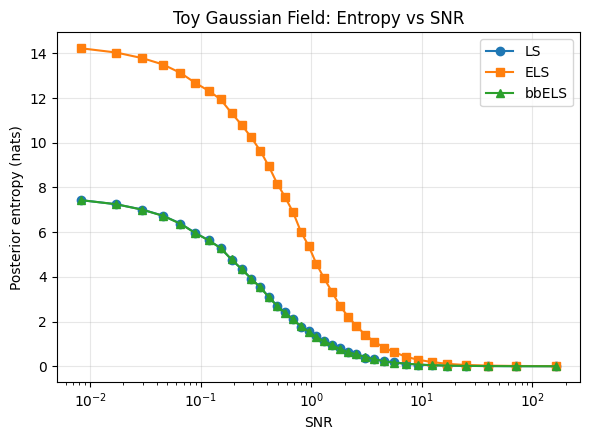

t=0.05 | SNR=1.641e+02 | H_LS=0.002, H_ELS=0.006, H_bbELS=0.002
t=0.08 | SNR=7.117e+01 | H_LS=0.003, H_ELS=0.013, H_bbELS=0.004
t=0.10 | SNR=3.936e+01 | H_LS=0.009, H_ELS=0.029, H_bbELS=0.009
t=0.13 | SNR=2.481e+01 | H_LS=0.017, H_ELS=0.057, H_bbELS=0.018
t=0.15 | SNR=1.696e+01 | H_LS=0.030, H_ELS=0.108, H_bbELS=0.029
t=0.18 | SNR=1.225e+01 | H_LS=0.048, H_ELS=0.190, H_bbELS=0.047
t=0.20 | SNR=9.208e+00 | H_LS=0.074, H_ELS=0.292, H_bbELS=0.078
t=0.23 | SNR=7.126e+00 | H_LS=0.118, H_ELS=0.431, H_bbELS=0.118
t=0.26 | SNR=5.642e+00 | H_LS=0.169, H_ELS=0.629, H_bbELS=0.159
t=0.28 | SNR=4.546e+00 | H_LS=0.239, H_ELS=0.836, H_bbELS=0.225
t=0.31 | SNR=3.714e+00 | H_LS=0.319, H_ELS=1.099, H_bbELS=0.308
t=0.33 | SNR=3.069e+00 | H_LS=0.392, H_ELS=1.411, H_bbELS=0.425
t=0.36 | SNR=2.558e+00 | H_LS=0.531, H_ELS=1.799, H_bbELS=0.533
t=0.38 | SNR=2.147e+00 | H_LS=0.645, H_ELS=2.224, H_bbELS=0.630
t=0.41 | SNR=1.812e+00 | H_LS=0.798, H_ELS=2.711, H_bbELS=0.778
t=0.44 | SNR=1.536e+00 | H_LS=0.943, H_E

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4.5))

axes.plot(results["snr"], results["LS"], "o-", label="LS")
axes.plot(results["snr"], results["ELS"], "s-", label="ELS")
axes.plot(results["snr"], results["bbELS"], "^-", label="bbELS")
axes.set_xscale("log")
axes.set_xlabel("SNR")
axes.set_ylabel("Posterior entropy (nats)")
axes.set_title(f"{cfg.dataset_name}: Entropy vs SNR")
axes.grid(alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()

for i in range(len(results["t"])):
    print(
        f"t={results['t'][i]:.2f} | SNR={results['snr'][i]:.3e} | "
        f"H_LS={results['LS'][i]:.3f}, H_ELS={results['ELS'][i]:.3f}, H_bbELS={results['bbELS'][i]:.3f}"
    )


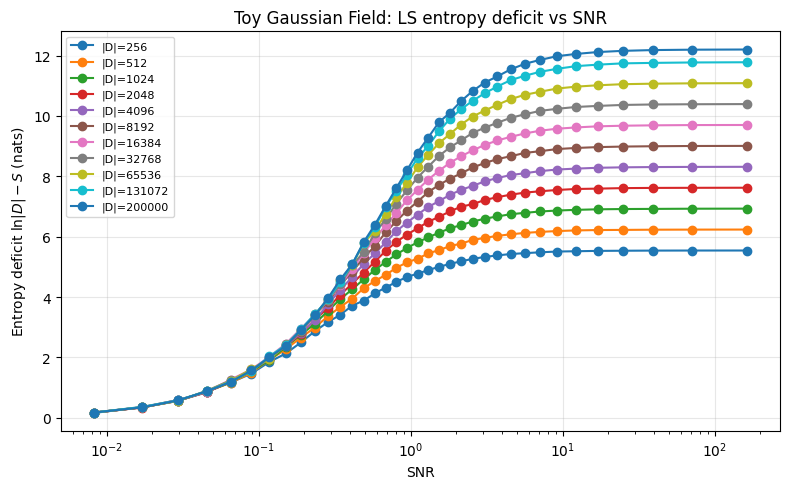

In [34]:
# Plot entropy deficit only (uses stored entropy_deficit_by_n, no recomputation)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for n_train in n_train_list:
    ax.plot(snr_grid, entropy_deficit_by_n[n_train], "o-", label=f"|D|={n_train}")
ax.set_xscale("log")
ax.set_xlabel("SNR")
ax.set_ylabel(r"Entropy deficit $\ln|D| - S$ (nats)")
ax.set_title(f"{cfg.dataset_name}: LS entropy deficit vs SNR")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Histogram of FFT `k_mag` vs normalized measure

This compares the empirical distribution of discrete FFT magnitudes `k_mag` on the 2D grid to the continuum normalized measure density

\[
\rho_\mu(k)=\frac{k}{N}, \qquad \int_{\Lambda_{IR}}^{\Lambda_{UV}}\rho_\mu(k)\,dk=P,
\]

where \(P\) is the patch pixel count.

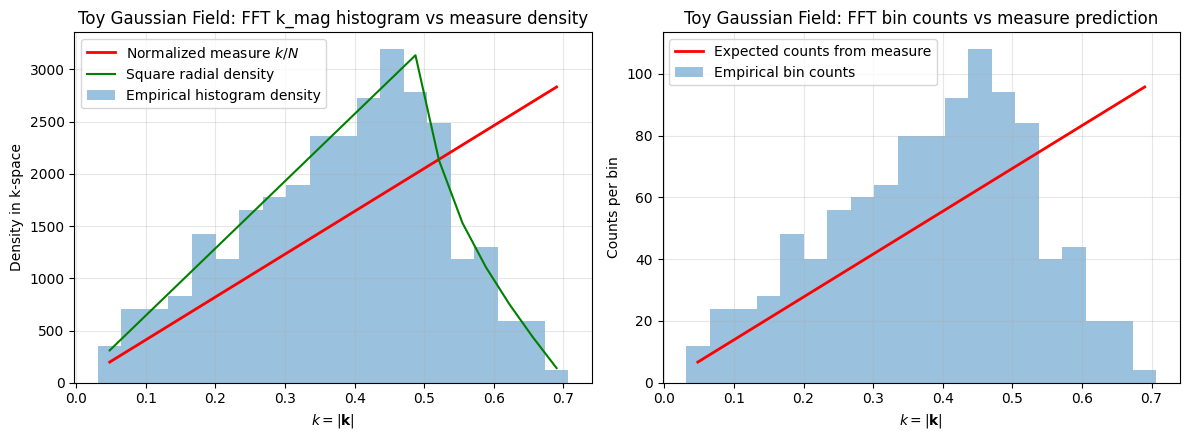

Total nonzero frequencies in histogram: 1022
Total expected nonzero count from measure over [IR, UV]: 1024.000
Patch pixels P: 1024


In [102]:
# Discrete FFT magnitudes from the same 2D frequency lattice
k_vals = k_mag.reshape(-1)
k_vals_nz = k_vals[k_vals > 0.0]

# Histogram on [lambda_ir, lambda_uv]
nbins = 20
counts, edges = np.histogram(k_vals_nz, bins=nbins, range=(lambda_ir, lambda_uv))
centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)

# Empirical density: counts per unit k
rho_emp = counts / widths

# Continuum normalized measure density rho_mu(k) = k / N with ∫ rho_mu dk = patch_pixels
integral_k = 0.5 * (lambda_uv**2 - lambda_ir**2)
N = integral_k / patch_pixels
rho_mu = centers / N

# Square radial density (same scale as histogram: s so support is (0, lambda_uv])
s_square = lambda_uv / np.sqrt(2)
rho_square_raw = square_radial_density(centers, s_square)
R_fine = np.linspace(1e-8, np.sqrt(2) * s_square, 500)
integral_square = np.trapz(square_radial_density(R_fine, s_square), R_fine)
rho_square_norm = rho_square_raw * (patch_pixels / integral_square)

# Optional: expected bin counts under continuum measure
expected_counts = 0.5 * ((edges[1:]**2 - edges[:-1]**2) / N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(centers, rho_emp, width=widths, alpha=0.45, label="Empirical histogram density")
axes[0].plot(centers, rho_mu, "r-", linewidth=2.0, label=r"Normalized measure $k/N$")
axes[0].plot(centers, rho_square_norm, "g-", linewidth=1.5, label="Square radial density")
axes[0].set_xlabel(r"$k=|\mathbf{k}|$")
axes[0].set_ylabel("Density in k-space")
axes[0].set_title(f"{cfg.dataset_name}: FFT k_mag histogram vs measure density")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(centers, counts, width=widths, alpha=0.45, label="Empirical bin counts")
axes[1].plot(centers, expected_counts, "r-", linewidth=2.0, label="Expected counts from measure")
axes[1].set_xlabel(r"$k=|\mathbf{k}|$")
axes[1].set_ylabel("Counts per bin")
axes[1].set_title(f"{cfg.dataset_name}: FFT bin counts vs measure prediction")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total nonzero frequencies in histogram: {int(np.sum(counts))}")
print(f"Total expected nonzero count from measure over [IR, UV]: {float(np.sum(expected_counts)):.3f}")
print(f"Patch pixels P: {patch_pixels}")

## Entropy deficit vs continuum and discrete MI

Same entropy deficit curves (no recomputation) with the analytic continuum and discrete mutual information approximations for comparison.

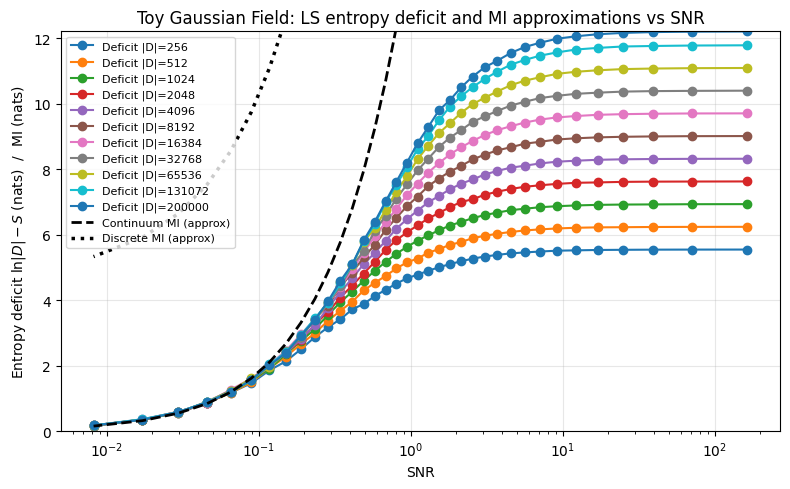

In [50]:
# Plot only (no recomputation): entropy deficit from stored entropy_deficit_by_n; MI from continuum_mutual_information and discrete_mutual_information
alpha=1.7
continuum_MI_nats = np.array([continuum_mutual_information(s, effective_amplitude, alpha, lambda_ir, lambda_uv, patch_pixels) for s in snr_grid])
discrete_MI_nats = np.array([discrete_mutual_information(s, effective_amplitude, alpha, k_mag, include_zero_mode=True) for s in snr_grid])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for n_train in n_train_list:
    ax.plot(snr_grid, entropy_deficit_by_n[n_train], "o-", label=f"Deficit |D|={n_train}")
ax.plot(snr_grid, continuum_MI_nats, "k--", linewidth=2, label="Continuum MI (approx)")
ax.plot(snr_grid, discrete_MI_nats, "k:", linewidth=2.5, label="Discrete MI (approx)")
ax.set_ylim(0, np.log(max(n_train_list)))
ax.set_xscale("log")
ax.set_xlabel("SNR")
ax.set_ylabel(r"Entropy deficit $\ln|D|-S$ (nats)  /  MI (nats)")
ax.set_title(f"{cfg.dataset_name}: LS entropy deficit and MI approximations vs SNR")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Discrete mutual information on FFT lattice

Define the discrete analytic quantity

\[
I_{\mathrm{disc}}(\mathrm{SNR}) = \frac{1}{2}\sum_{\mathbf{k}\in\mathcal{K}_{\mathrm{FFT}},\,|\mathbf{k}|>0}
\log\left(1+\mathrm{SNR}\cdot A\,|\mathbf{k}|^{-\alpha}\right).
\]

This is an explicit sum over the discrete FFT frequencies.

In [ ]:
def discrete_mutual_information(snr_value, amplitude, alpha, k_mag_grid, include_zero_mode=False):
    """Explicit discrete sum: 0.5 * sum_k log(1 + SNR * A * |k|^{-alpha})."""
    k_flat = np.asarray(k_mag_grid, dtype=np.float64).reshape(-1)
    if include_zero_mode:
        # Avoid singular k^{-alpha} at k=0; keep formula well-defined numerically.
        k_flat = np.maximum(k_flat, 1e-12)
    else:
        k_flat = k_flat[k_flat > 0.0]

    terms = 0.5 * np.log(1.0 + snr_value * amplitude * np.power(k_flat, -alpha))
    return float(np.sum(terms))


# Evaluate across the same SNR grid used above
discrete_mi = [
    discrete_mutual_information(s, effective_amplitude, cfg.alpha, k_mag, include_zero_mode=False)
    for s in results["snr"]
]

# Optional entropy-style prediction from the discrete MI
# S_approx_disc = max(0, log|D| - I_disc)
analytic_ls_discrete = [max(0.0, np.log(D_ls) - mi) / np.log(2.0) for mi in discrete_mi]
analytic_els_discrete = [max(0.0, np.log(D_els) - mi) / np.log(2.0) for mi in discrete_mi]

print("Computed discrete_mutual_information on SNR grid.")
print("Example:", {"snr": results["snr"][0], "I_disc": discrete_mi[0]})

## Continuum vs discrete mutual information (re-added)

This compares the continuum MI approximation

\[
I_{\mathrm{cont}}(\mathrm{SNR})=\frac{1}{2}\int_{\Lambda_{IR}}^{\Lambda_{UV}}\frac{k}{N}\log\left(1+\mathrm{SNR}\,A\,k^{-\alpha}\right)dk
\]

with the explicit discrete FFT-lattice sum

\[
I_{\mathrm{disc}}(\mathrm{SNR})=\frac{1}{2}\sum_{|\mathbf{k}|>0}\log\left(1+\mathrm{SNR}\,A\,|\mathbf{k}|^{-\alpha}\right).
\]

In [94]:
def continuum_mutual_information(snr_value, amplitude, alpha, lambda_ir, lambda_uv, patch_pixels, num_k=4096):
    """Continuum MI in nats using the same normalized measure as the entropy approximation."""
    k = np.linspace(lambda_ir, lambda_uv, num_k, dtype=np.float64)
    integral_k = 0.5 * (lambda_uv**2 - lambda_ir**2)
    N = integral_k / patch_pixels
    integrand = 0.5 * np.log(1.0 + snr_value * amplitude * np.power(k, -alpha))
    return float(np.trapz((k / N) * integrand, k))

def continuum_mutual_information_no_cutoff(snr_value, amplitude, alpha, patch_pixels, num_k=4096):
    return 0

def discrete_mutual_information_plot_ready(snr_value, amplitude, alpha, k_mag_grid):
    """Explicit discrete FFT sum for MI in nats, excluding zero mode."""
    k_flat = np.asarray(k_mag_grid, dtype=np.float64).reshape(-1)
    k_flat = k_flat[k_flat > 0.0]
    return float(np.sum(0.5 * np.log(1.0 + snr_value * amplitude * np.power(k_flat, -alpha))))


snr_grid = np.array(results["snr"], dtype=np.float64)
continuum_mi = [
    continuum_mutual_information(s, effective_amplitude, cfg.alpha, lambda_ir, lambda_uv, patch_pixels)
    for s in snr_grid
]
discrete_mi_plot = [
    discrete_mutual_information_plot_ready(s, effective_amplitude, cfg.alpha, k_mag)
    for s in snr_grid
]

plt.figure(figsize=(6.5, 4.5))
plt.plot(snr_grid, continuum_mi, "o--", label="Continuum MI")
plt.plot(snr_grid, discrete_mi_plot, "s-", label="Discrete MI")
plt.xscale("log")
plt.xlabel("SNR")
plt.ylabel("Mutual information (nats)")
plt.title(f"{cfg.dataset_name}: Continuum vs discrete MI")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Mean absolute MI gap (nats):", float(np.mean(np.abs(np.array(continuum_mi) - np.array(discrete_mi_plot)))))

NameError: name 'patch_pixels' is not defined

In [ ]:
# Plot continuum mutual information only
continuum_MI_only = np.array([continuum_mutual_information(s, effective_amplitude, cfg.alpha, lambda_ir, lambda_uv, patch_pixels) for s in snr_grid])
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(snr_grid, continuum_MI_only, "o-", color="C0")
ax.set_xscale("log")
ax.set_xlabel("SNR")
ax.set_ylabel("Continuum MI (nats)")
ax.set_title(f"{cfg.dataset_name}: Continuum mutual information")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Empirical Fourier covariance vs \(k\)

This checks the data covariance in Fourier space by estimating, for each discrete mode,

\[
\widehat{\mathrm{Cov}}\big(\hat{x}(\mathbf{k})\big) \approx \mathbb{E}\,|\hat{x}(\mathbf{k})|^2,
\]

then plotting covariance against \(|\mathbf{k}|\). A binned radial average is also shown with a fitted \(Ck^{-\alpha}\) reference.

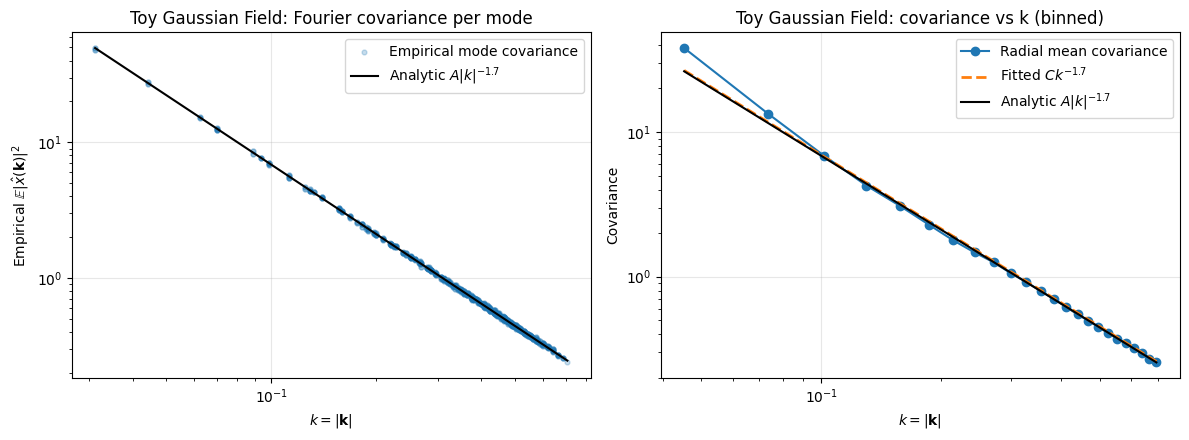

Fitted amplitude C for C*k^{-alpha}: 0.13859027624601747


In [87]:
# Use full FFT (not rFFT) to inspect empirical covariance by mode
cov_samples = min(4096, len(train_dataset))
x_np = np.stack([train_dataset[i][0][0].numpy() for i in range(cov_samples)], axis=0)  # [n_cov, H, W]
fft_coeff = np.fft.fft2(x_np, axes=(-2, -1), norm="ortho")

# Empirical per-mode covariance proxy for zero-mean complex coefficients
emp_cov_mode = np.mean(np.abs(fft_coeff) ** 2, axis=0)  # [H, W]

# Frequency lattice and |k|
freq = np.fft.fftfreq(cfg.image_size, d=1.0)
ky_full, kx_full = np.meshgrid(freq, freq, indexing="ij")
k_mag_full = np.sqrt(kx_full**2 + ky_full**2)

k_flat = k_mag_full.reshape(-1)
cov_flat = emp_cov_mode.reshape(-1)
mask = k_flat > 0.0
k_flat = k_flat[mask]
cov_flat = cov_flat[mask]

# Radial binning for readability
nbins = 24
edges = np.linspace(k_flat.min(), k_flat.max(), nbins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
radial_cov = np.full(nbins, np.nan)
for i in range(nbins):
    bmask = (k_flat >= edges[i]) & (k_flat < edges[i + 1])
    if np.any(bmask):
        radial_cov[i] = np.mean(cov_flat[bmask])

# Fit only amplitude C in C*k^{-alpha} (log-space least squares)
valid = np.isfinite(radial_cov) & (radial_cov > 0) & (centers > 0)
logC = np.mean(np.log(radial_cov[valid]) + cfg.alpha * np.log(centers[valid]))
C_fit = float(np.exp(logC))
ref_curve = C_fit * np.power(centers, -cfg.alpha)

# Analytic formula: A |k|^{-alpha}  (log variance = log A - alpha * log(k))
analytic_cov = effective_amplitude * np.power(centers, -cfg.alpha)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(k_flat, cov_flat, s=12, alpha=0.25, label="Empirical mode covariance")
k_line = np.linspace(k_flat.min(), k_flat.max(), 200)
axes[0].plot(k_line, effective_amplitude * np.power(k_line, -cfg.alpha), "k-", linewidth=1.5, label=rf"Analytic $A|k|^{{-{cfg.alpha:.1f}}}$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$k=|\mathbf{k}|$")
axes[0].set_ylabel(r"Empirical $\mathbb{E}|\hat{x}(\mathbf{k})|^2$")
axes[0].set_title(f"{cfg.dataset_name}: Fourier covariance per mode")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(centers[valid], radial_cov[valid], "o-", label="Radial mean covariance")
axes[1].plot(centers[valid], ref_curve[valid], "--", linewidth=2.0, label=rf"Fitted $Ck^{{-{cfg.alpha:.1f}}}$")
axes[1].plot(centers[valid], analytic_cov[valid], "k-", linewidth=1.5, label=rf"Analytic $A|k|^{{-{cfg.alpha:.1f}}}$")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$k=|\mathbf{k}|$")
axes[1].set_ylabel("Covariance")
axes[1].set_title(f"{cfg.dataset_name}: covariance vs k (binned)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Fitted amplitude C for C*k^{-alpha}:", C_fit)

In [ ]:
effective_amplitude